# OLCI vs PACE BRT on the same profiles

Join the CHLA-Z methods table to `olci_l3_matchups.parquet` on `profile_id`. Keep rows where **all 11 OLCI bands** are finite (PACE Rrs is already complete on these ids).

Then fit the same BRT as `notebooks/methods_fit_BRT_CHLA_z.ipynb` (`HistGradientBoostingRegressor`, `log10(CHLA)`, `solar_hour` + `type`, `random_state=42`) twice on the **same train/test ids**:

1. **PACE-full** — ~172 `pace_Rrs_*` bands  
2. **OLCI-11** — the 11 `olci_Rrs_*` bands  
3. **PACE-11** — nearest PACE band to each OLCI center (control: same wavelengths, same sensor)

Kernel: `gobgc`. Does not import `ml_utils`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

OLCI_BANDS = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
OLCI_COLS = [f"olci_Rrs_{nm}" for nm in OLCI_BANDS]
PACE_11 = {
    400: "pace_Rrs_400",
    412: "pace_Rrs_413",
    443: "pace_Rrs_442",
    490: "pace_Rrs_490",
    510: "pace_Rrs_510",
    560: "pace_Rrs_560",
    620: "pace_Rrs_620",
    665: "pace_Rrs_665",
    674: "pace_Rrs_673",
    681: "pace_Rrs_681",
    709: "pace_Rrs_709",
}
PACE_11_COLS = [PACE_11[nm] for nm in OLCI_BANDS]
EXTRA = ["solar_hour", "type"]
BRT_KW = dict(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    validation_fraction=0.1,
    early_stopping=True,
    random_state=42,
)

DATA = Path("/Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data")
HERE = Path("/Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama")
if not (DATA / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p.parent / "chla-z" / "brt_training_data"
        if (cand / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
            DATA = cand
        if (p / "contributor_folders" / "nama").is_dir():
            HERE = p / "contributor_folders" / "nama"

OLCI_FILE = HERE / "olci_l3_matchups.parquet"
print("DATA:", DATA)
print("OLCI:", OLCI_FILE, "exists", OLCI_FILE.is_file())

DATA: /Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data
OLCI: /Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama/olci_l3_matchups.parquet exists True


## Methods table (Argo + OOI, solar hour, biofouling)

Same merge as the methods notebook. Solar hour is inlined so we do not import `ml_utils`. Drop duplicate OOI `profile_id`s so the join is one row per id.

In [2]:
def add_solar_hour(df, time="time", lon="lon"):
    out = df.copy()
    t = pd.to_datetime(out[time], utc=True)
    utc_hour = t.dt.hour + t.dt.minute / 60.0 + t.dt.second / 3600.0
    lon_e = out[lon].astype(float)
    if np.nanmax(lon_e.to_numpy()) > 180:
        lon_e = ((lon_e + 180) % 360) - 180
    out["solar_hour"] = (utc_hour.to_numpy() + lon_e.to_numpy() / 15.0) % 24.0
    return out


def parse_depth_bin(col):
    _, a, b = col.split("_")
    return int(a), int(b)


def flag_deep_biofouling(df, deep_bins, min_valid=5, min_chl=1.0, max_spread=2):
    bad = []
    for pid, sub in df.groupby("profile_id"):
        vals = sub[deep_bins].to_numpy(dtype=float).ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size < min_valid:
            continue
        if (vals.min() > min_chl) and ((vals.max() - vals.min()) < max_spread):
            bad.append(pid)
    return bad

argo = pd.read_parquet(DATA / "CHLA_argo_profiles_plus_PACE.parquet")
argo = argo.rename(columns={"LATITUDE": "lat", "LONGITUDE": "lon", "TIME": "time"})
rrs_cols = [c for c in argo.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
chl_cols = [c for c in argo.columns if c.startswith("CHLA_") and c[-1].isdigit()]
keep = ["profile_id", "time", "lat", "lon"] + rrs_cols + chl_cols + ["pace_chlor_a", "pace_Kd_490"]
argo = argo[keep].copy()
argo["type"] = 0

ooi = pd.read_parquet(DATA / "CHLA_ooi_profiles_plus_PACE.parquet")
ooi = ooi[keep].copy()
ooi["type"] = 1

dataset = pd.concat([argo, ooi], ignore_index=True)
dataset = add_solar_hour(dataset)
dataset = dataset.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
print("after merge + PACE Rrs dropna:", dataset.shape)

chl_cols = sorted(
    [c for c in dataset.columns if c.startswith("CHLA_") and c[-1].isdigit()],
    key=lambda c: parse_depth_bin(c)[0],
)
deep_bins = [c for c in chl_cols if 100 <= 0.5 * sum(parse_depth_bin(c)) <= 200]
bad_ids = flag_deep_biofouling(dataset, deep_bins)
print(f"flagged {len(bad_ids)} biofouled profile_id")
dataset = dataset[~dataset["profile_id"].isin(bad_ids)].reset_index(drop=True)
n0 = len(dataset)
dataset = dataset.drop_duplicates("profile_id").reset_index(drop=True)
print(f"unique profile_id: {n0} -> {len(dataset)}")

after merge + PACE Rrs dropna: (5540, 200)
flagged 20 biofouled profile_id
unique profile_id: 5510 -> 4712


## Inner join OLCI and keep complete spectra

In [3]:
olci = pd.read_parquet(OLCI_FILE)
olci_keep = ["profile_id", "olci_sat"] + OLCI_COLS
dataset = dataset.merge(olci[olci_keep], on="profile_id", how="inner")
print("inner join on profile_id:", len(dataset))

ok = dataset[OLCI_COLS].notna().all(axis=1)
print(f"all 11 OLCI finite: {int(ok.sum())}/{len(dataset)}")
dataset = dataset.loc[ok].reset_index(drop=True)
print("comparison table:", dataset.shape)
print(dataset["type"].map({0: "argo", 1: "ooi"}).value_counts())
print("olci_sat:")
print(dataset["olci_sat"].value_counts())

inner join on profile_id: 4712
all 11 OLCI finite: 2369/4712
comparison table: (2369, 212)
type
argo    1467
ooi      902
Name: count, dtype: int64
olci_sat:
olci_sat
S3A    1363
S3B    1006
Name: count, dtype: int64


##  Shared train/test split

Split **after** the OLCI filter, by `profile_id`, `random_state=42`. Both models see the same ids. Per-depth fits still drop rows with NaN CHLA in that bin.

In [4]:
ids = dataset["profile_id"].to_numpy()
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)
train_idx = dataset.index[dataset["profile_id"].isin(train_ids)].to_numpy()
test_idx = dataset.index[dataset["profile_id"].isin(test_ids)].to_numpy()
print(f"train {len(train_idx)}  test {len(test_idx)}")

PACE_COLS = [c for c in dataset.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
MODELS = {
    "PACE-full": PACE_COLS,
    "PACE-11": PACE_11_COLS,
    "OLCI-11": OLCI_COLS,
}
print({k: len(v) for k, v in MODELS.items()})

train 1895  test 474
{'PACE-full': 172, 'PACE-11': 11, 'OLCI-11': 11}


## Surface BRT (`CHLA_0_10`)

In [5]:
def xy_for_bin(df, y_col, rrs):
    tab = df[[y_col] + rrs + EXTRA].copy()
    tab = tab.rename(columns={y_col: "y"})
    tab = tab.where(tab["y"] > 0)
    tab["y"] = np.log10(tab["y"])
    tab = tab.dropna(subset=["y"])
    return tab[rrs + EXTRA], tab["y"]


def fit_one(name, rrs, y_col="CHLA_0_10"):
    Xtr, ytr = xy_for_bin(dataset.loc[train_idx], y_col, rrs)
    Xte, yte = xy_for_bin(dataset.loc[test_idx], y_col, rrs)
    model = HistGradientBoostingRegressor(**BRT_KW).fit(Xtr, ytr)
    pred = model.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    print(f"{name:10s}  n_train={len(Xtr):4d}  n_test={len(Xte):4d}  R2={r2:.3f}  RMSE={rmse:.3f}  (log10 CHLA)")
    return model, r2, rmse

surface = {}
for name, rrs in MODELS.items():
    surface[name] = fit_one(name, rrs)

PACE-full   n_train=1224  n_test= 322  R2=0.762  RMSE=0.354  (log10 CHLA)
PACE-11     n_train=1224  n_test= 322  R2=0.769  RMSE=0.348  (log10 CHLA)
OLCI-11     n_train=1224  n_test= 322  R2=0.774  RMSE=0.344  (log10 CHLA)


## One BRT per depth bin

Same `train_idx` / `test_idx` for every depth. Metrics are on `log10(CHLA)`.

In [6]:
def metrics_vs_depth(name, rrs):
    rows = []
    models = {}
    for col in chl_cols:
        a, b = parse_depth_bin(col)
        z = 0.5 * (a + b)
        Xtr, ytr = xy_for_bin(dataset.loc[train_idx], col, rrs)
        Xte, yte = xy_for_bin(dataset.loc[test_idx], col, rrs)
        if len(Xtr) < 20 or len(Xte) < 10:
            rows.append({"model": name, "bin": col, "z": z, "n_test": len(Xte),
                         "r2": np.nan, "rmse": np.nan})
            continue
        model = HistGradientBoostingRegressor(**BRT_KW).fit(Xtr, ytr)
        models[col] = model
        pred = model.predict(Xte)
        rows.append({
            "model": name, "bin": col, "z": z, "n_test": len(Xte),
            "r2": r2_score(yte, pred),
            "rmse": float(np.sqrt(mean_squared_error(yte, pred))),
        })
        print(f"{name:10s} {col:14s}  n_test={len(Xte):4d}  R2={rows[-1]['r2']:.3f}  RMSE={rows[-1]['rmse']:.3f}")
    return pd.DataFrame(rows), models

parts = []
fitted = {}
for name, rrs in MODELS.items():
    print("===", name, "===")
    tab, models = metrics_vs_depth(name, rrs)
    parts.append(tab)
    fitted[name] = models
metrics = pd.concat(parts, ignore_index=True)
metrics

=== PACE-full ===
PACE-full  CHLA_0_10       n_test= 322  R2=0.762  RMSE=0.354
PACE-full  CHLA_10_20      n_test= 206  R2=0.841  RMSE=0.288
PACE-full  CHLA_20_30      n_test= 251  R2=0.831  RMSE=0.280
PACE-full  CHLA_30_40      n_test= 268  R2=0.794  RMSE=0.297
PACE-full  CHLA_40_50      n_test= 262  R2=0.755  RMSE=0.269
PACE-full  CHLA_50_60      n_test= 254  R2=0.590  RMSE=0.311
PACE-full  CHLA_60_70      n_test= 256  R2=0.469  RMSE=0.342
PACE-full  CHLA_70_80      n_test= 261  R2=0.378  RMSE=0.341
PACE-full  CHLA_80_90      n_test= 212  R2=0.296  RMSE=0.352
PACE-full  CHLA_90_100     n_test= 211  R2=0.285  RMSE=0.354
PACE-full  CHLA_100_110    n_test= 200  R2=0.325  RMSE=0.379
PACE-full  CHLA_110_120    n_test= 203  R2=0.352  RMSE=0.364
PACE-full  CHLA_120_130    n_test= 215  R2=0.406  RMSE=0.363
PACE-full  CHLA_130_140    n_test= 208  R2=0.288  RMSE=0.418
PACE-full  CHLA_140_150    n_test= 216  R2=0.301  RMSE=0.421
PACE-full  CHLA_150_160    n_test= 209  R2=0.213  RMSE=0.452
PACE-f

,model,bin,z,n_test,r2,rmse
0,PACE-full,CHLA_0_10,5.0,322,0.761557,0.353506
1,PACE-full,CHLA_10_20,15.0,206,0.841481,0.288038
2,PACE-full,CHLA_20_30,25.0,251,0.831379,0.280463
3,PACE-full,CHLA_30_40,35.0,268,0.794301,0.296757
4,PACE-full,CHLA_40_50,45.0,262,0.754934,0.268698
5,PACE-full,CHLA_50_60,55.0,254,0.590012,0.310669
6,PACE-full,CHLA_60_70,65.0,256,0.468731,0.342006
7,PACE-full,CHLA_70_80,75.0,261,0.378265,0.341167
8,PACE-full,CHLA_80_90,85.0,212,0.296482,0.351786
9,PACE-full,CHLA_90_100,95.0,211,0.284957,0.353927


## RMSE and R² vs depth

rmse                            r2                      n_test  \
model   OLCI-11   PACE-11 PACE-full   OLCI-11   PACE-11 PACE-full OLCI-11   
z                                                                           
5.0    0.344220  0.347857  0.353506  0.773919  0.769117  0.761557   322.0   
15.0   0.317799  0.303359  0.288038  0.807031  0.824169  0.841481   206.0   
25.0   0.267472  0.284718  0.280463  0.846637  0.826223  0.831379   251.0   
35.0   0.294614  0.293895  0.296757  0.797261  0.798250  0.794301   268.0   
45.0   0.262441  0.271240  0.268698  0.766216  0.750276  0.754934   262.0   
55.0   0.300407  0.296733  0.310669  0.616649  0.625968  0.590012   254.0   
65.0   0.335997  0.352586  0.342006  0.487234  0.435351  0.468731   256.0   
75.0   0.350340  0.339007  0.341167  0.344385  0.386115  0.378265   261.0   
85.0   0.365225  0.352726  0.351786  0.241703  0.292717  0.296482   212.0   
95.0   0.341079  0.356639  0.353927  0.335929  0.273955  0.284957   211.0   
105.0  0.361217  0.382476  0.378785  0.386267  0.311899  0.325117   200.0   
115.0  0.351151  0.369644  0.364289  0.398297  0.333254  0.352430   203.0   
125.0  0.343678  0.347939  0.362550  0.465864  0.452538  0.405594   215.0   
135.0  0.400388  0.409386  0.418384  0.348205  0.318580  0.288297   208.0   
145.0  0.405229  0.409643  0.420629  0.351205  0.336993  0.300954   216.0   
155.0  0.465640  0.436129  0.452277  0.165326  0.267771  0.212544   209.0   
165.0  0.448106  0.439165  0.433333  0.192273  0.224183  0.244654   224.0   
175.0  0.473192  0.430256  0.432554  0.090959  0.248442  0.240390   216.0   
185.0  0.447321  0.422887  0.414161  0.167615  0.256067  0.286449   203.0   
195.0  0.434726  0.399973  0.400546  0.130554  0.264010  0.261898   202.0   

                         
model PACE-11 PACE-full  
z                        
5.0     322.0     322.0  
15.0    206.0     206.0  
25.0    251.0     251.0  
35.0    268.0     268.0  
45.0    262.0     262.0  
55.0    254.0     254.0  
65.0    256.0     256.0  
75.0    261.0     261.0  
85.0    212.0     212.0  
95.0    211.0     211.0  
105.0   200.0     200.0  
115.0   203.0     203.0  
125.0   215.0     215.0  
135.0   208.0     208.0  
145.0   216.0     216.0  
155.0   209.0     209.0  
165.0   224.0     224.0  
175.0   216.0     216.0  
185.0   203.0     203.0  
195.0   202.0     202.0

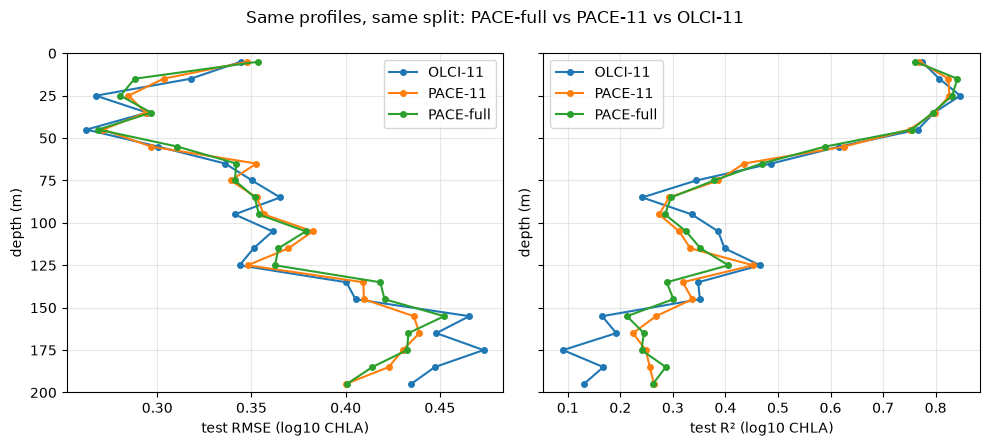

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for name, sub in metrics.groupby("model"):
    sub = sub.sort_values("z")
    axes[0].plot(sub["rmse"], sub["z"], marker="o", ms=4, label=name)
    axes[1].plot(sub["r2"], sub["z"], marker="o", ms=4, label=name)
axes[0].set_xlabel("test RMSE (log10 CHLA)")
axes[1].set_xlabel("test R² (log10 CHLA)")
axes[0].set_ylim(200, 0)  # surface at top; sharey copies this to both
for ax in axes:
    ax.set_ylabel("depth (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Same profiles, same split: PACE-full vs PACE-11 vs OLCI-11")
fig.tight_layout()

wide = metrics.pivot(index="z", columns="model", values=["rmse", "r2", "n_test"])
wide

## DCM / shape

Point RMSE can look fine while the subsurface maximum is in the wrong place.

For test profiles with ≥8 finite CHLA bins:

- **Peak depth / peak CHLA / 0–200 m integral** as before  
- **SCM** — in situ peak ≥ 50 m **and** peak / surface CHLA > 1.3 (not the old ≥25 m cut)  
- **Detection** — did the model also put a SCM below 50 m with the same ratio rule?  
- **Hit rate** — |Δz| ≤ 10 m or 20 m on true SCMs  
- **Profile *r*** — Pearson and Spearman correlation of CHLA(z) on shared bins  
- **Prominence** — peak / surface CHLA (RMSE on log10 ratio)  

In situ uses observed bins; each BRT uses its full predicted profile. Re-run the all-depth fit if `fitted` is missing.


test profiles with >=8 CHLA bins: 228 / 474
in situ SCM (peak >= 50 m and peak/surf > 1.3): 115 / 228

all profiles with enough bins
    model   n  z_peak_MAE_m  z_peak_bias_m  hit_10m  hit_20m  log10_peak_RMSE  log10_prom_RMSE  mean_r  mean_rs  int_RMSE
PACE-full 228        21.886        -10.395    0.570    0.772            0.436            0.383   0.774    0.801    28.767
  PACE-11 228        22.588        -11.184    0.557    0.746            0.434            0.385   0.776    0.799    28.300
  OLCI-11 228        21.974        -11.184    0.557    0.754            0.434            0.393   0.776    0.807    30.106

SCM only (in situ peak >= 50 m, ratio > 1.3)
    model   n  z_peak_MAE_m  z_peak_bias_m  hit_10m  hit_20m  log10_peak_RMSE  log10_prom_RMSE  mean_r  mean_rs  int_RMSE
PACE-full 115        15.739         -6.696    0.583    0.800            0.250            0.383   0.769    0.840    11.486
  PACE-11 115        17.391         -8.000    0.548    0.765            0.244            

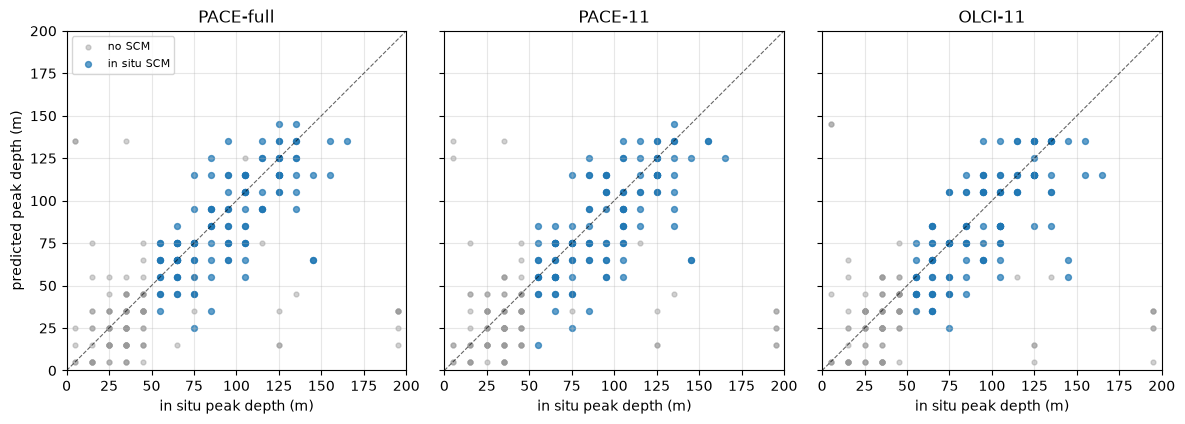

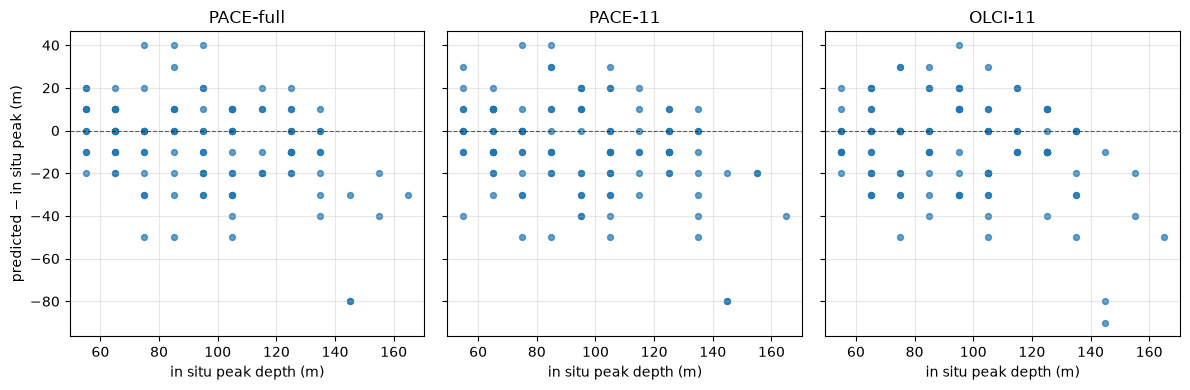

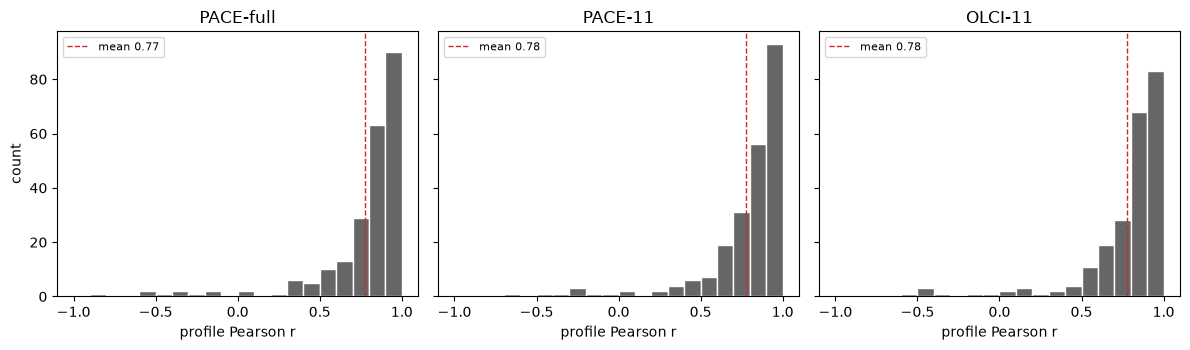

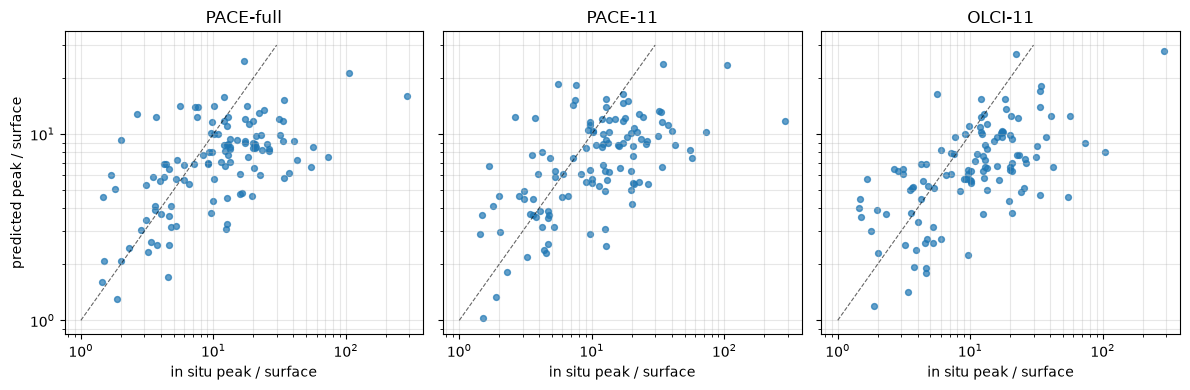

In [8]:
def _x_row(row, rrs):
    return pd.DataFrame([{c: row[c] for c in list(rrs) + EXTRA}])


def pred_profile_lin(row, model_name):
    models = fitted[model_name]
    rrs = MODELS[model_name]
    X = _x_row(row, rrs)
    z, y = [], []
    for col in chl_cols:
        if col not in models:
            continue
        a, b = parse_depth_bin(col)
        z.append(0.5 * (a + b))
        y.append(float(10 ** models[col].predict(X)[0]))
    return np.asarray(z), np.asarray(y)


def obs_profile_lin(row):
    z, y = [], []
    for col in chl_cols:
        val = row[col]
        if pd.notna(val) and val > 0:
            a, b = parse_depth_bin(col)
            z.append(0.5 * (a + b))
            y.append(float(val))
    return np.asarray(z), np.asarray(y)


def shape_stats(z, y):
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y) & (y > 0)
    if int(ok.sum()) < 3:
        return np.nan, np.nan, np.nan
    i = int(np.argmax(y[ok]))
    zz, yy = z[ok], y[ok]
    return float(zz[i]), float(yy[i]), float(np.sum(yy) * 10.0)


MIN_BINS = 8
SCM_Z = 50.0          # peak at or below 50–60 m bin
SCM_RATIO = 1.3       # peak / surface CHLA
HIT_M = (10.0, 20.0)


def chl_at(z, y, z0=5.0):
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isclose(z, z0) & np.isfinite(y) & (y > 0)
    return float(y[m][0]) if m.any() else np.nan


def is_scm(z_peak, chl_peak, chl_surf, z_min=SCM_Z, ratio=SCM_RATIO):
    if not np.isfinite(z_peak) or not np.isfinite(chl_peak) or not np.isfinite(chl_surf):
        return False
    if chl_surf <= 0:
        return False
    return (z_peak >= z_min) and (chl_peak / chl_surf > ratio)


def profile_r(z_o, y_o, z_p, y_p):
    d = pd.DataFrame({"z": z_o, "o": y_o}).merge(
        pd.DataFrame({"z": z_p, "p": y_p}), on="z",
    )
    d = d.loc[np.isfinite(d["o"]) & np.isfinite(d["p"]) & (d["o"] > 0) & (d["p"] > 0)]
    if len(d) < 5 or d["o"].std() == 0 or d["p"].std() == 0:
        return np.nan, np.nan
    pear = float(np.corrcoef(d["o"].to_numpy(), d["p"].to_numpy())[0, 1])
    spear = float(d["o"].corr(d["p"], method="spearman"))
    return pear, spear


test_df = dataset.loc[test_idx]
n_obs = test_df[chl_cols].notna().sum(axis=1)
shape_df = test_df.loc[n_obs >= MIN_BINS].copy()
print(f"test profiles with >={MIN_BINS} CHLA bins: {len(shape_df)} / {len(test_df)}")

rows = []
for _, row in shape_df.iterrows():
    z_o, y_o = obs_profile_lin(row)
    zp_o, yp_o, int_o = shape_stats(z_o, y_o)
    surf_o = chl_at(z_o, y_o)
    rec = {
        "profile_id": row["profile_id"],
        "z_peak_obs": zp_o,
        "chl_peak_obs": yp_o,
        "chl_surf_obs": surf_o,
        "int_obs": int_o,
        "prom_obs": yp_o / surf_o if np.isfinite(surf_o) and surf_o > 0 else np.nan,
        "is_scm": is_scm(zp_o, yp_o, surf_o),
    }
    for name in MODELS:
        z_p, y_p = pred_profile_lin(row, name)
        zp, yp, integ = shape_stats(z_p, y_p)
        surf_p = chl_at(z_p, y_p)
        rec[f"z_peak_{name}"] = zp
        rec[f"chl_peak_{name}"] = yp
        rec[f"chl_surf_{name}"] = surf_p
        rec[f"int_{name}"] = integ
        rec[f"prom_{name}"] = yp / surf_p if np.isfinite(surf_p) and surf_p > 0 else np.nan
        rec[f"is_scm_{name}"] = is_scm(zp, yp, surf_p)
        rec[f"r_{name}"], rec[f"rs_{name}"] = profile_r(z_o, y_o, z_p, y_p)
    rows.append(rec)

shape = pd.DataFrame(rows)
n_scm = int(shape["is_scm"].sum())
print(f"in situ SCM (peak >= {SCM_Z:.0f} m and peak/surf > {SCM_RATIO}): {n_scm} / {len(shape)}")


def err_table(df):
    out = []
    for name in MODELS:
        dz = df[f"z_peak_{name}"] - df["z_peak_obs"]
        dlog = np.log10(df[f"chl_peak_{name}"]) - np.log10(df["chl_peak_obs"])
        dint = df[f"int_{name}"] - df["int_obs"]
        dprom = np.log10(df[f"prom_{name}"]) - np.log10(df["prom_obs"])
        hit = {f"hit_{int(h)}m": float(np.nanmean(np.abs(dz) <= h)) for h in HIT_M}
        out.append({
            "model": name,
            "n": len(df),
            "z_peak_MAE_m": float(np.nanmean(np.abs(dz))),
            "z_peak_bias_m": float(np.nanmean(dz)),
            **hit,
            "log10_peak_RMSE": float(np.sqrt(np.nanmean(dlog ** 2))),
            "log10_prom_RMSE": float(np.sqrt(np.nanmean(dprom ** 2))),
            "mean_r": float(np.nanmean(df[f"r_{name}"])),
            "mean_rs": float(np.nanmean(df[f"rs_{name}"])),
            "int_RMSE": float(np.sqrt(np.nanmean(dint ** 2))),
        })
    return pd.DataFrame(out)


print("\nall profiles with enough bins")
print(err_table(shape).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nSCM only (in situ peak >= {SCM_Z:.0f} m, ratio > {SCM_RATIO})")
print(err_table(shape.loc[shape["is_scm"]]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nSCM detection (same depth + ratio rule on predicted profile)")
det = []
for name in MODELS:
    pred = shape[f"is_scm_{name}"].astype(bool)
    obs = shape["is_scm"].astype(bool)
    tp = int((pred & obs).sum())
    fp = int((pred & ~obs).sum())
    fn = int((~pred & obs).sum())
    tn = int((~pred & ~obs).sum())
    det.append({
        "model": name,
        "obs_SCM": int(obs.sum()),
        "pred_SCM": int(pred.sum()),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "recall": tp / obs.sum() if obs.sum() else np.nan,
        "precision": tp / pred.sum() if pred.sum() else np.nan,
        "miss_rate": fn / obs.sum() if obs.sum() else np.nan,
    })
print(pd.DataFrame(det).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

prom_cols = ["prom_obs"] + [f"prom_{name}" for name in MODELS]
print("\nprominence (peak / surface) on in situ SCMs")
print(shape.loc[shape["is_scm"], prom_cols].describe(percentiles=[0.5, 0.9, 0.99]).to_string(float_format=lambda v: f"{v:.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
lims = [0, 200]
for ax, name in zip(axes, MODELS):
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.6)
    m = shape["is_scm"]
    ax.scatter(shape.loc[~m, "z_peak_obs"], shape.loc[~m, f"z_peak_{name}"],
               s=12, alpha=0.45, c="0.6", label="no SCM")
    ax.scatter(shape.loc[m, "z_peak_obs"], shape.loc[m, f"z_peak_{name}"],
               s=18, alpha=0.7, label="in situ SCM")
    ax.set_title(name)
    ax.set_xlabel("in situ peak depth (m)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("predicted peak depth (m)")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, name in zip(axes, MODELS):
    m = shape["is_scm"]
    dz = shape.loc[m, f"z_peak_{name}"] - shape.loc[m, "z_peak_obs"]
    ax.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
    ax.scatter(shape.loc[m, "z_peak_obs"], dz, s=18, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("in situ peak depth (m)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("predicted − in situ peak (m)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
bins = np.linspace(-1, 1, 21)
for ax, name in zip(axes, MODELS):
    r = shape[f"r_{name}"].dropna()
    ax.hist(r, bins=bins, color="0.4", edgecolor="white")
    ax.axvline(r.mean(), color="C3", ls="--", lw=1, label=f"mean {r.mean():.2f}")
    ax.set_title(name)
    ax.set_xlabel("profile Pearson r")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
m = shape["is_scm"] & np.isfinite(shape["prom_obs"])
for ax, name in zip(axes, MODELS):
    ax.plot([1, 30], [1, 30], "k--", lw=0.8, alpha=0.6)
    ax.scatter(shape.loc[m, "prom_obs"], shape.loc[m, f"prom_{name}"], s=18, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("in situ peak / surface")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
axes[0].set_ylabel("predicted peak / surface")
plt.tight_layout()
plt.show()


## Which bands matter?

Two views on the **same train/test ids**:

1. **PCA of Rrs** (train only, bands standardized) — which wavelengths dominate *spectral variance*.
2. **Permutation importance** on the fitted BRTs (test RMSE of `log10(CHLA)`) — which bands the *model* actually uses.

PCA is not feature importance. Use the permutation bars for “influence on prediction.”

### PCA of Rrs (fit on train)

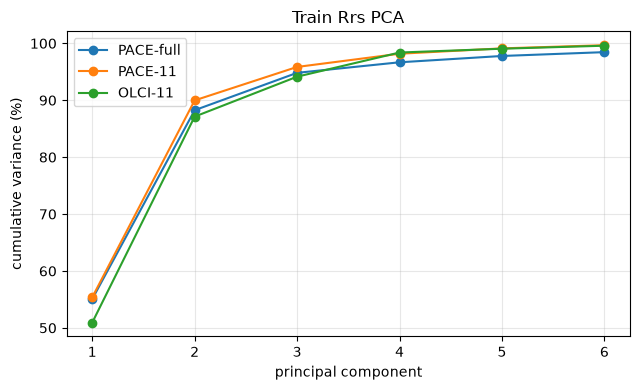

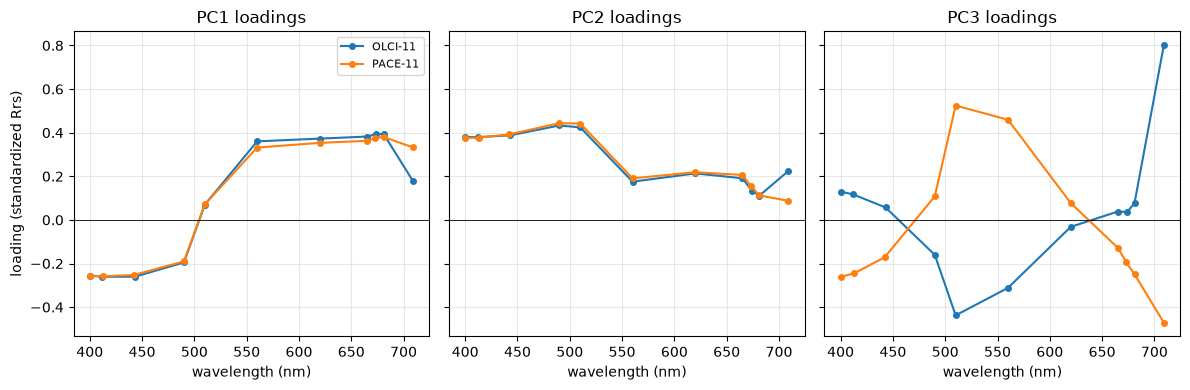

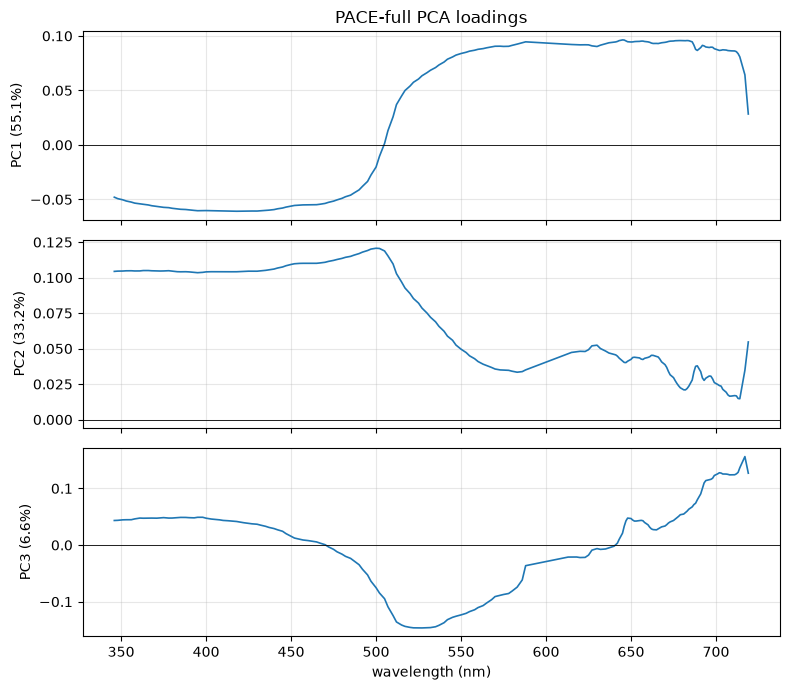

/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


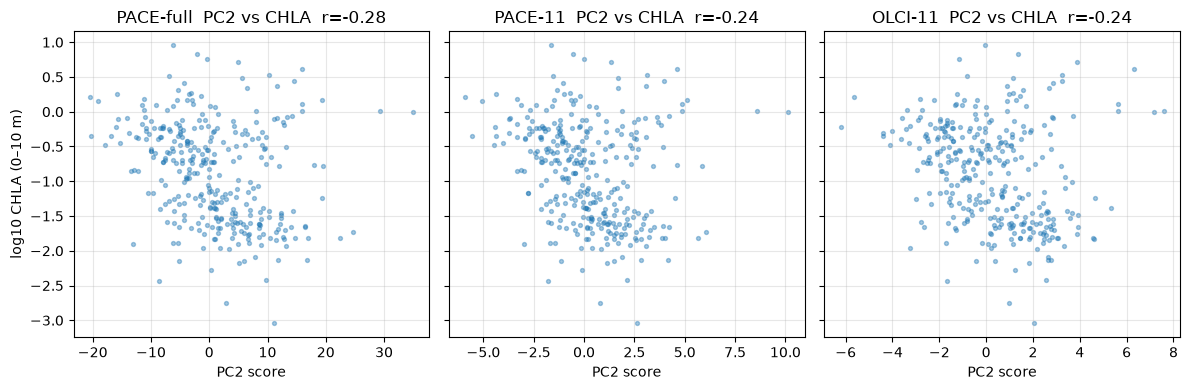

explained variance ratio (first 3 PCs)
  PACE-full   [0.55059518 0.33190317 0.06566045]  cum=0.948
  PACE-11     [0.5536163  0.34611905 0.05877489]  cum=0.959
  OLCI-11     [0.50927211 0.36194448 0.07017921]  cum=0.941


In [9]:
def rrs_nm(col):
    return float(str(col).rsplit("_", 1)[-1])


def pca_on_train(cols, n_comp=6):
    X = dataset.loc[train_idx, cols].to_numpy(dtype=float)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    n = min(n_comp, Xs.shape[1], Xs.shape[0])
    pca = PCA(n_components=n, random_state=42).fit(Xs)
    waves = np.array([rrs_nm(c) for c in cols])
    return pca, scaler, waves


pcas = {name: pca_on_train(cols) for name, cols in MODELS.items()}

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, (pca, _, _) in pcas.items():
    ax.plot(
        np.arange(1, pca.n_components_ + 1),
        np.cumsum(pca.explained_variance_ratio_) * 100,
        "o-", label=name,
    )
ax.set_xlabel("principal component")
ax.set_ylabel("cumulative variance (%)")
ax.set_title("Train Rrs PCA")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, k in zip(axes, range(3)):
    for name in ("OLCI-11", "PACE-11"):
        pca, _, waves = pcas[name]
        ax.plot(waves, pca.components_[k], "o-", ms=4, label=name)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"PC{k+1} loadings")
    ax.set_xlabel("wavelength (nm)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("loading (standardized Rrs)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

pca_f, _, waves_f = pcas["PACE-full"]
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for ax, k in zip(axes, range(3)):
    ax.plot(waves_f, pca_f.components_[k], lw=1.2)
    ax.axhline(0, color="k", lw=0.6)
    ev = 100 * pca_f.explained_variance_ratio_[k]
    ax.set_ylabel(f"PC{k+1} ({ev:.1f}%)")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("wavelength (nm)")
axes[0].set_title("PACE-full PCA loadings")
plt.tight_layout()
plt.show()

# PC scores vs surface log10 CHLA on test (same rows as the BRT)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
y_col = "CHLA_0_10"
for ax, name in zip(axes, MODELS):
    cols = MODELS[name]
    pca, scaler, _ = pcas[name]
    Xte, yte = xy_for_bin(dataset.loc[test_idx], y_col, cols)
    scores = pca.transform(scaler.transform(Xte[cols]))
    ax.scatter(scores[:, 1] if scores.shape[1] > 1 else scores[:, 0], yte, s=8, alpha=0.4)
    pc_i = 2 if scores.shape[1] > 1 else 1
    r = np.corrcoef(scores[:, pc_i - 1], yte)[0, 1]
    ax.set_title(f"{name}  PC{pc_i} vs CHLA  r={r:.2f}")
    ax.set_xlabel(f"PC{pc_i} score")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("log10 CHLA (0–10 m)")
plt.tight_layout()
plt.show()

print("explained variance ratio (first 3 PCs)")
for name, (pca, _, _) in pcas.items():
    ev = pca.explained_variance_ratio_[:3]
    print(f"  {name:10s}  {ev}  cum={ev.sum():.3f}")

### Permutation importance (test RMSE)

Shuffle one feature at a time on the **test** set. Height is the increase in RMSE of `log10(CHLA)`. Uses `fitted` from section 5 (re-run that cell if `fitted` is missing). `n_repeats=8`.

=== CHLA_0_10 ===
PACE-full
     feature  delta_rmse
pace_Rrs_442      0.0719
pace_Rrs_440      0.0450
  solar_hour      0.0298
pace_Rrs_435      0.0237
pace_Rrs_470      0.0137
PACE-11
     feature  delta_rmse
pace_Rrs_442      0.4083
pace_Rrs_681      0.1001
pace_Rrs_560      0.0722
pace_Rrs_490      0.0500
  solar_hour      0.0380
OLCI-11
     feature  delta_rmse
olci_Rrs_443      0.2762
olci_Rrs_681      0.1620
olci_Rrs_560      0.0862
  solar_hour      0.0458
olci_Rrs_620      0.0296
=== CHLA_150_160 ===
PACE-full
     feature  delta_rmse
pace_Rrs_420      0.0229
        type      0.0096
pace_Rrs_712      0.0044
pace_Rrs_714      0.0040
pace_Rrs_430      0.0039
PACE-11
     feature  delta_rmse
pace_Rrs_413      0.0504
pace_Rrs_709      0.0471
pace_Rrs_560      0.0173
        type      0.0166
pace_Rrs_442      0.0079
OLCI-11
     feature  delta_rmse
olci_Rrs_412      0.0587
olci_Rrs_443      0.0254
olci_Rrs_709      0.0198
        type      0.0144
olci_Rrs_620      0.0044


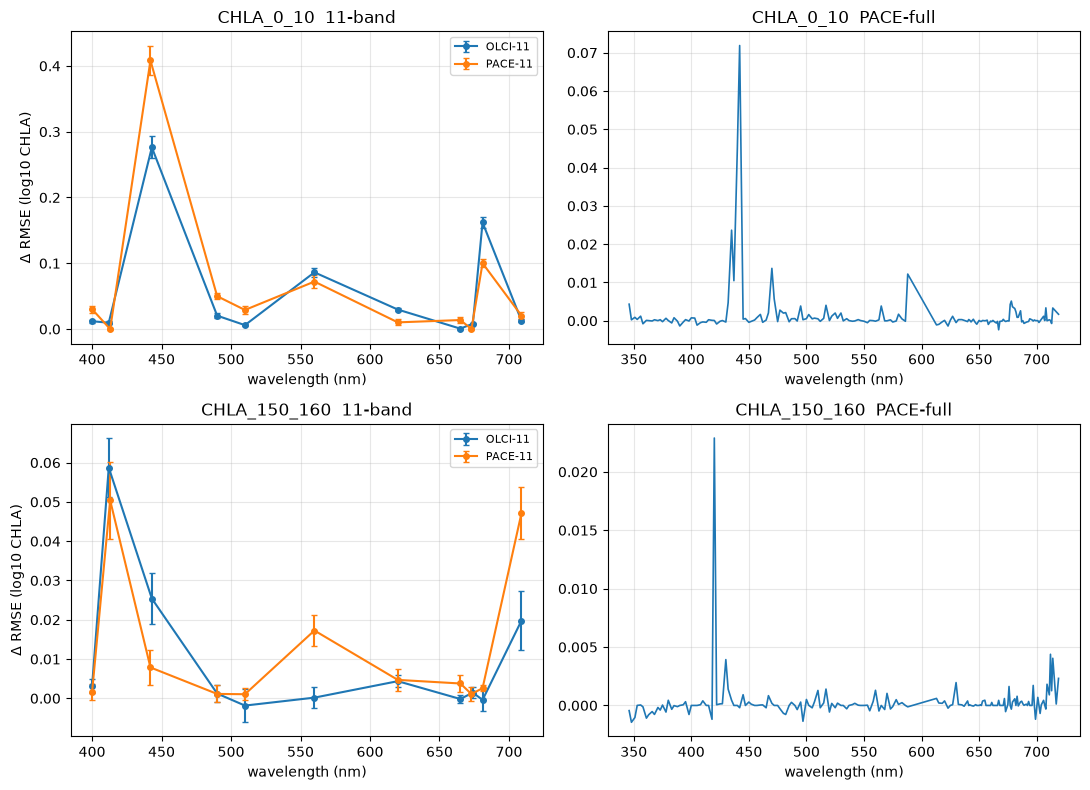

extra features (solar_hour, type)
    model          bin    feature  delta_rmse
PACE-full    CHLA_0_10 solar_hour      0.0298
PACE-full    CHLA_0_10       type      0.0004
  PACE-11    CHLA_0_10 solar_hour      0.0380
  PACE-11    CHLA_0_10       type      0.0021
  OLCI-11    CHLA_0_10 solar_hour      0.0458
  OLCI-11    CHLA_0_10       type      0.0085
PACE-full CHLA_150_160       type      0.0096
PACE-full CHLA_150_160 solar_hour     -0.0041
  PACE-11 CHLA_150_160       type      0.0166
  PACE-11 CHLA_150_160 solar_hour     -0.0056
  OLCI-11 CHLA_150_160       type      0.0144
  OLCI-11 CHLA_150_160 solar_hour     -0.0036


In [10]:
def permutation_table(name, y_col, n_repeats=8):
    rrs = MODELS[name]
    if y_col not in fitted[name]:
        raise KeyError(f"no fitted model {name} / {y_col}; re-run section 5")
    Xte, yte = xy_for_bin(dataset.loc[test_idx], y_col, rrs)
    res = permutation_importance(
        fitted[name][y_col], Xte, yte,
        n_repeats=n_repeats,
        random_state=42,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    tab = pd.DataFrame({
        "model": name,
        "bin": y_col,
        "feature": Xte.columns,
        "delta_rmse": res.importances_mean,
        "delta_rmse_std": res.importances_std,
    })
    tab["kind"] = np.where(tab["feature"].isin(rrs), "rrs", "extra")
    tab["nm"] = np.nan
    is_rrs = tab["kind"] == "rrs"
    tab.loc[is_rrs, "nm"] = tab.loc[is_rrs, "feature"].map(rrs_nm)
    return tab.sort_values("delta_rmse", ascending=False)


IMP_BINS = ["CHLA_0_10", "CHLA_150_160"]
imp_parts = []
for y_col in IMP_BINS:
    print("===", y_col, "===")
    for name in MODELS:
        tab = permutation_table(name, y_col)
        imp_parts.append(tab)
        top = tab.head(5)[["feature", "delta_rmse"]]
        print(name)
        print(top.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

imp = pd.concat(imp_parts, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
for col_i, y_col in enumerate(IMP_BINS):
    ax = axes[col_i, 0]
    for name in ("OLCI-11", "PACE-11"):
        sub = imp[(imp["model"] == name) & (imp["bin"] == y_col) & (imp["kind"] == "rrs")].sort_values("nm")
        ax.errorbar(sub["nm"], sub["delta_rmse"], yerr=sub["delta_rmse_std"],
                    fmt="o-", ms=4, capsize=2, label=name)
    ax.set_title(f"{y_col}  11-band")
    ax.set_xlabel("wavelength (nm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[col_i, 1]
    sub = imp[(imp["model"] == "PACE-full") & (imp["bin"] == y_col) & (imp["kind"] == "rrs")].sort_values("nm")
    ax.plot(sub["nm"], sub["delta_rmse"], lw=1.2)
    ax.set_title(f"{y_col}  PACE-full")
    ax.set_xlabel("wavelength (nm)")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Δ RMSE (log10 CHLA)")
axes[1, 0].set_ylabel("Δ RMSE (log10 CHLA)")
plt.tight_layout()
plt.show()

print("extra features (solar_hour, type)")
print(
    imp.loc[imp["kind"] == "extra", ["model", "bin", "feature", "delta_rmse"]]
    .to_string(index=False, float_format=lambda v: f"{v:.4f}")
)

## Example validation profiles

Randomly draw **15 test** `profile_id`s (`random_state=42`), named **P1–P15**. Prefer profiles with at least 8 finite CHLA bins so the vertical structure is visible.

Then: map those 15, then plot each as a 5×3 panel with **in situ** (Argo or OOI fluorometer), **OLCI-11**, **PACE-11**, and **PACE-full**. Predictions use the models already stored in `fitted`.

In [11]:
N_SHOW = 15
MIN_BINS = 8

test_df = dataset.loc[test_idx].copy()
n_obs = test_df[chl_cols].notna().sum(axis=1)
eligible = test_df.loc[n_obs >= MIN_BINS]
if len(eligible) < N_SHOW:
    eligible = test_df
    print(f"only {int((n_obs >= MIN_BINS).sum())} test profiles with >={MIN_BINS} bins; sampling from all test")

show = eligible.sample(n=N_SHOW, random_state=42).reset_index(drop=True)
show.insert(0, "label", [f"P{i}" for i in range(1, N_SHOW + 1)])
show["source"] = np.where(show["type"] == 0, "Argo", "OOI")
show["n_chl_bins"] = show[chl_cols].notna().sum(axis=1)

print(show[["label", "profile_id", "source", "lat", "lon", "time", "n_chl_bins"]].to_string(index=False))

label                               profile_id source        lat         lon                                time  n_chl_bins
   P1 ooi-ce04osps-sf01b-3a-flortd104_20250505    OOI  44.369353 -124.954108           2025-05-05 00:00:00+00:00          20
   P2                             2903863_0100   Argo  18.074800 -164.576200 2024-12-19 11:56:37.000999936+00:00          20
   P3                             1902456_0040   Argo -25.566300   54.261400 2024-06-01 08:13:13.000999936+00:00          20
   P4 ooi-cp14nepm-wfp01-04-flortk000_20241003    OOI  36.048870  -74.778600           2024-10-03 00:00:00+00:00          18
   P5                             4902600_0030   Argo  37.155399  -73.919479           2024-06-28 14:43:00+00:00          13
   P6 ooi-ce09ospm-wfp01-04-flortk000_20240927    OOI  46.852180 -124.974610           2024-09-27 00:00:00+00:00          17
   P7                             4902599_0066   Argo  35.532440  -62.560349           2024-07-27 07:34:00+00:00          14


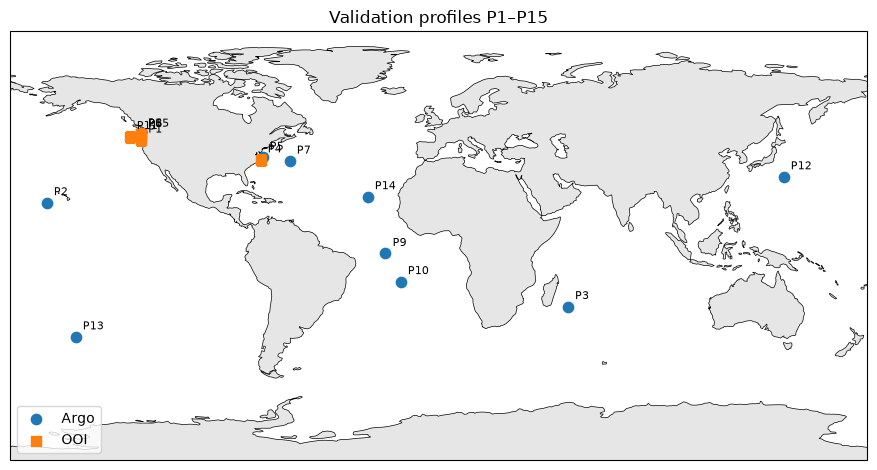

In [12]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    fig, ax = plt.subplots(figsize=(10, 4.8), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND, facecolor="0.9")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_global()
    transform = ccrs.PlateCarree()
except Exception as exc:
    print("cartopy unavailable, lon/lat scatter:", exc)
    fig, ax = plt.subplots(figsize=(10, 4.8))
    transform = None

for src, sub in show.groupby("source"):
    kw = dict(s=55, zorder=3, label=src)
    if transform is not None:
        kw["transform"] = transform
    marker = "o" if src == "Argo" else "s"
    ax.scatter(sub["lon"], sub["lat"], marker=marker, **kw)

for _, r in show.iterrows():
    text_kw = dict(fontsize=8, ha="left", va="bottom")
    if transform is not None:
        ax.text(r["lon"] + 3, r["lat"] + 2, r["label"], transform=transform, **text_kw)
    else:
        ax.text(r["lon"] + 3, r["lat"] + 2, r["label"], **text_kw)

ax.legend(loc="lower left")
ax.set_title("Validation profiles P1–P15")
if transform is None:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

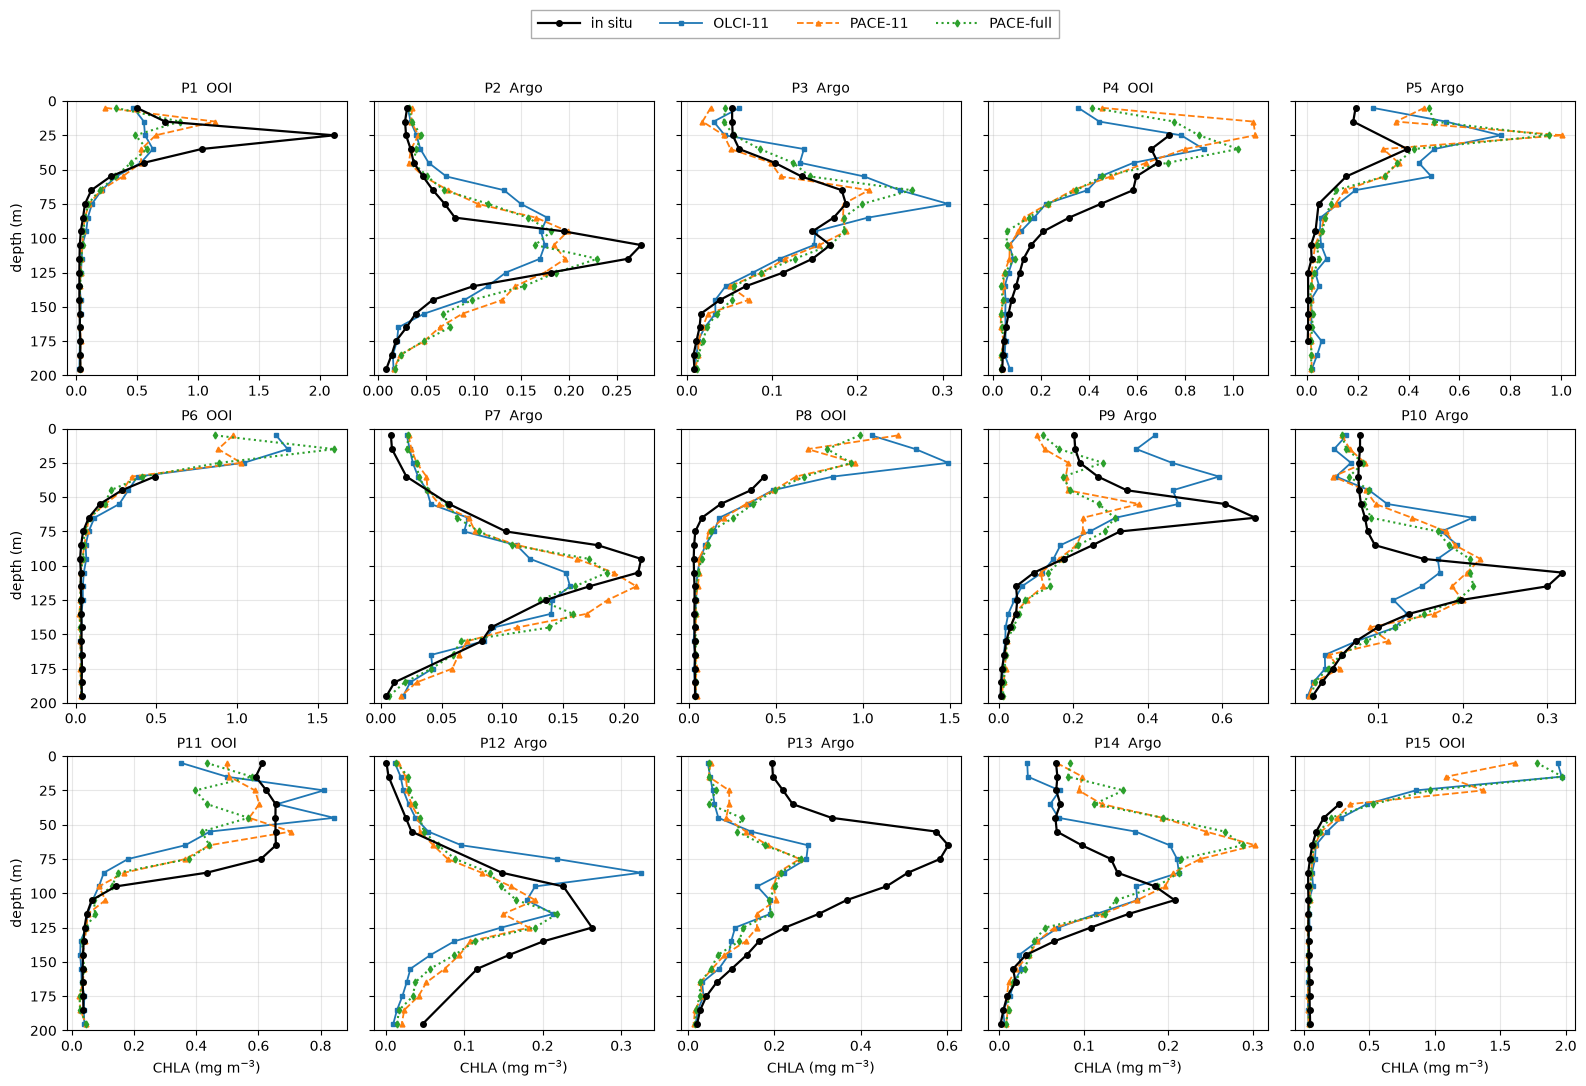

In [13]:
def x_row(row, rrs):
    return pd.DataFrame([{c: row[c] for c in rrs + EXTRA}])


def predict_profile(row, model_name):
    models = fitted[model_name]
    rrs = MODELS[model_name]
    X = x_row(row, rrs)
    z, yhat = [], []
    for col in chl_cols:
        if col not in models:
            continue
        a, b = parse_depth_bin(col)
        z.append(0.5 * (a + b))
        yhat.append(float(10 ** models[col].predict(X)[0]))
    return np.asarray(z), np.asarray(yhat)


def obs_profile(row):
    z, y = [], []
    for col in chl_cols:
        val = row[col]
        if pd.notna(val) and val > 0:
            a, b = parse_depth_bin(col)
            z.append(0.5 * (a + b))
            y.append(float(val))
    return np.asarray(z), np.asarray(y)


STYLES = {
    "in situ": dict(color="k", marker="o", ls="-", lw=1.6, ms=4, zorder=3),
    "OLCI-11": dict(color="C0", marker="s", ls="-", lw=1.3, ms=3.5),
    "PACE-11": dict(color="C1", marker="^", ls="--", lw=1.3, ms=3.5),
    "PACE-full": dict(color="C2", marker="d", ls=":", lw=1.5, ms=3.5),
}

fig, axes = plt.subplots(3, 5, figsize=(16, 11), sharey=True)
axes = np.asarray(axes).ravel()

for i, r in show.iterrows():
    ax = axes[i]
    z_obs, y_obs = obs_profile(r)
    ax.plot(y_obs, z_obs, label="in situ", **STYLES["in situ"])
    for name in ("OLCI-11", "PACE-11", "PACE-full"):
        z_hat, y_hat = predict_profile(r, name)
        ax.plot(y_hat, z_hat, label=name, **STYLES[name])
    ax.set_ylim(200, 0)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{r['label']}  {r['source']}", fontsize=10)
    if i % 5 == 0:
        ax.set_ylabel("depth (m)")
    if i >= 10:
        ax.set_xlabel("CHLA (mg m$^{-3}$)")

for ax in axes[N_SHOW:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()
fig.subplots_adjust(top=0.90)
fig.legend(
    handles, labels,
    loc="center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.97),
    frameon=True,
    fancybox=False,
    fontsize=10,
    handlelength=3,
    borderpad=0.5,
    edgecolor="0.6",
)
plt.show()

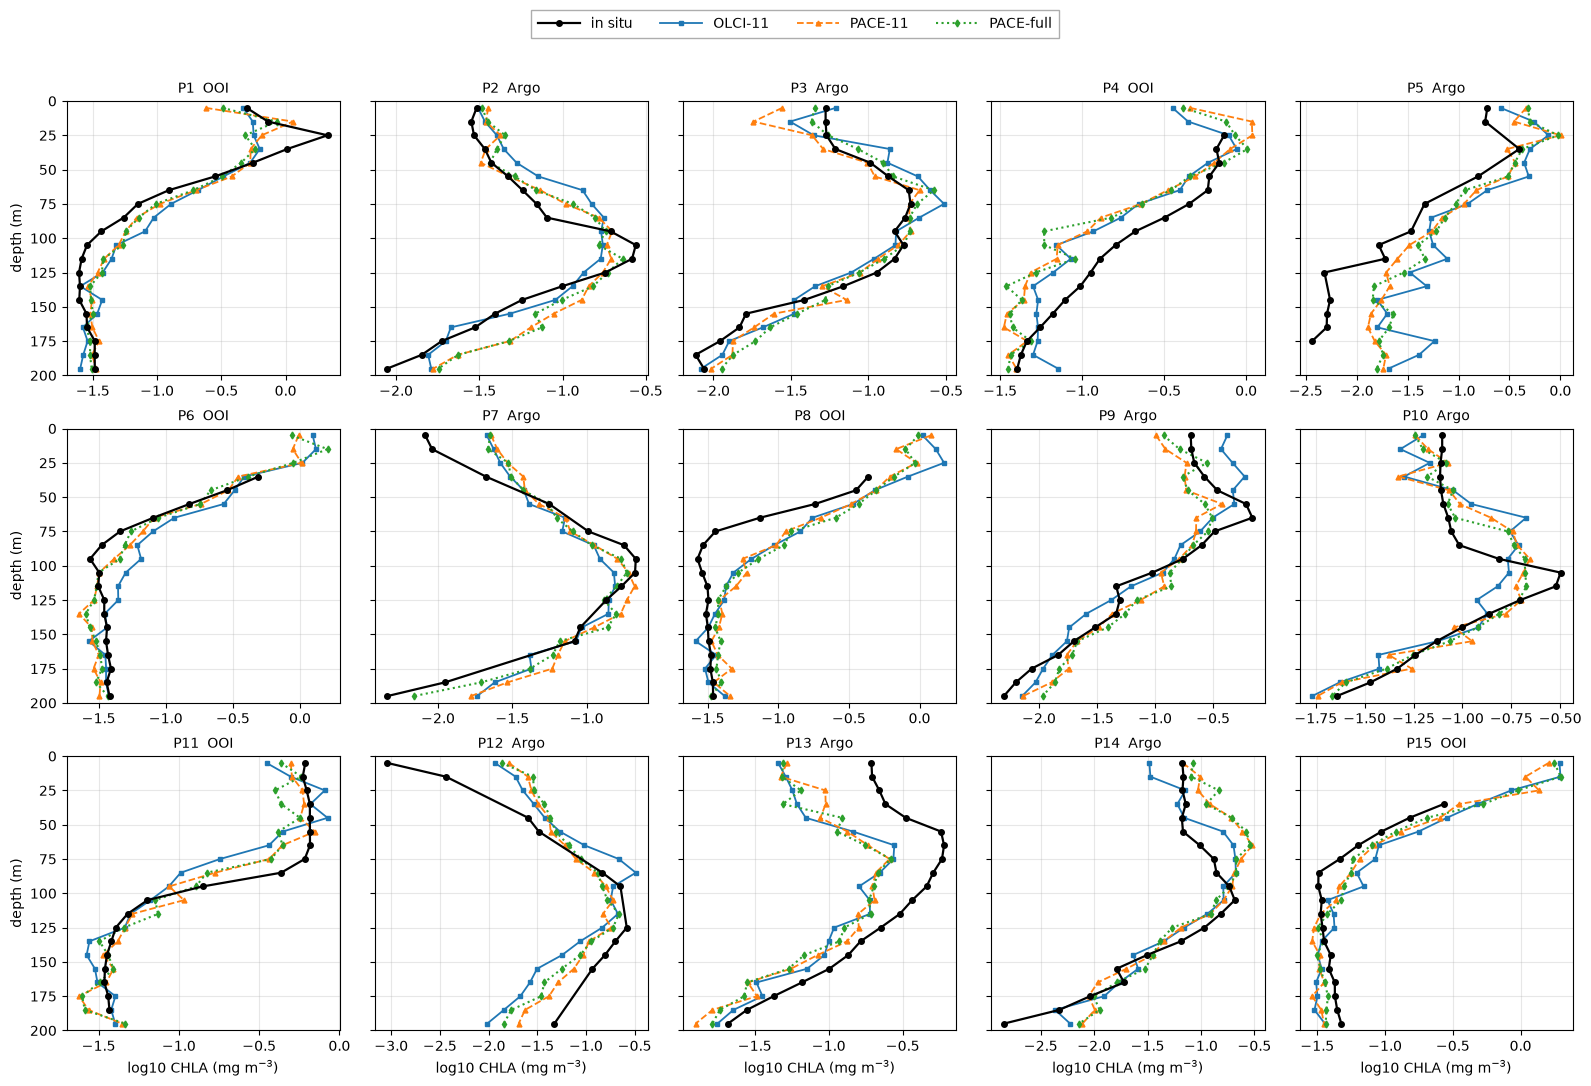

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(16, 11), sharey=True)
axes = np.asarray(axes).ravel()

for i, r in show.iterrows():
    ax = axes[i]
    z_obs, y_obs = obs_profile(r)
    ax.plot(np.log10(y_obs), z_obs, label="in situ", **STYLES["in situ"])
    for name in ("OLCI-11", "PACE-11", "PACE-full"):
        z_hat, y_hat = predict_profile(r, name)
        ax.plot(np.log10(y_hat), z_hat, label=name, **STYLES[name])
    ax.set_ylim(200, 0)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{r['label']}  {r['source']}", fontsize=10)
    if i % 5 == 0:
        ax.set_ylabel("depth (m)")
    if i >= 10:
        ax.set_xlabel("log10 CHLA (mg m$^{-3}$)")

for ax in axes[N_SHOW:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()
fig.subplots_adjust(top=0.90)
fig.legend(
    handles, labels,
    loc="center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.97),
    frameon=True,
    fancybox=False,
    fontsize=10,
    handlelength=3,
    borderpad=0.5,
    edgecolor="0.6",
)
plt.show()